# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [59]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [36]:
# Load the prepared dataset from Phase 3
DATA_PATH = r'D:\Churn Prediction And Analysis Project\Cell2Cell Data\Cell2Cell_Prepared_Data.csv'

df = pd.read_csv(DATA_PATH)
print(f"Loaded prepared dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded prepared dataset: 51047 rows x 123 columns


,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,Market_sea,Market_sew,Market_sfr,Market_sfu,Market_she,Market_slc,Market_slu,Market_stl,Market_vah,Churn
0,-1.033942,-0.640973,-1.129992,-0.405629,-0.697503,-0.622791,-0.999634,-1.693738,-0.799909,-0.570341,...,1,0,0,0,0,0,0,0,0,1
1,-1.265594,-1.122124,-1.362826,-0.704436,-0.697503,-0.622791,0.030054,0.202066,-0.872316,-0.797170,...,0,0,0,0,0,0,0,0,0,1
2,-0.571298,-1.126728,-0.384922,-0.704436,-0.697503,-0.622791,0.043514,0.202066,-0.926621,-0.797170,...,0,0,0,0,0,0,0,0,0,0
3,0.891977,1.875287,1.338054,0.777648,-0.697503,-0.622791,1.113583,1.010277,2.367889,1.697956,...,0,0,0,0,0,0,0,0,0,0
4,-1.260637,-1.145146,-1.362826,-0.704436,-0.697503,-0.622791,0.056974,0.182110,-0.926621,-0.797170,...,0,0,0,0,0,0,0,0,0,1


Features importance

In [37]:
target="Churn"
X = df.drop(columns=[target])
y = df[target]

In [38]:
#make sure all colums are numeric 
print(X.select_dtypes(include="object").columns)

Index([], dtype='object')


In [39]:
# Data Validation

print("Object Columns:")
print(X.select_dtypes(include="object").columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

Object Columns:
[]

Missing Values:
0

Duplicate Records:
0


In [40]:
# ==========================================
# Split Data
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (40837, 122)
Testing Set : (10210, 122)


In [41]:
# ==========================================
# Feature Selection using Random Forest
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_selector.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_selector.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(importance)

,Feature,Importance
0,CurrentEquipmentDays,5.205567e-02
1,RevenuePerMinute,4.100777e-02
2,PercChangeMinutes,4.037935e-02
3,MonthsInService,3.814727e-02
4,UsagePerDevice,3.810480e-02
...,...,...
117,Market_sfu,1.044322e-05
118,Market_inu,1.218694e-06
119,Market_law,7.444021e-07
120,Market_hop,4.151348e-07


In [42]:
print(importance["Importance"].describe())

count    1.220000e+02
mean     8.196721e-03
std      1.184251e-02
min      1.993966e-07
25%      1.010202e-03
50%      2.693734e-03
75%      9.484055e-03
max      5.205567e-02
Name: Importance, dtype: float64


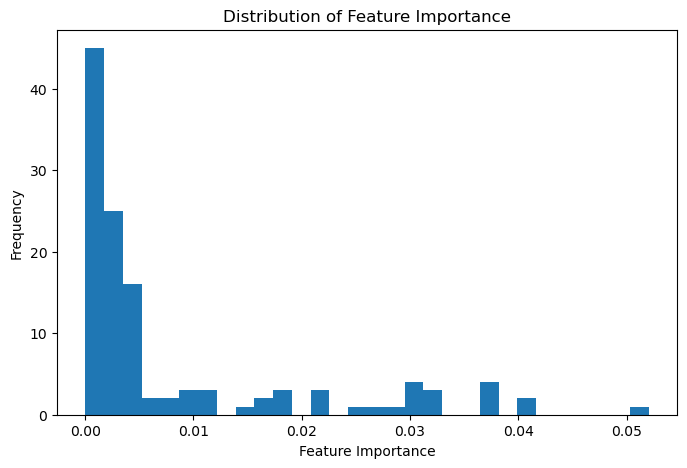

In [43]:
plt.figure(figsize=(8,5))

plt.hist(importance["Importance"], bins=30)

plt.xlabel("Feature Importance")
plt.ylabel("Frequency")
plt.title("Distribution of Feature Importance")

plt.show()

In [44]:
print(len(importance))

print((importance["Importance"] < 0.001).sum())

print((importance["Importance"] < 0.0005).sum())

print((importance["Importance"] < 0.0001).sum())

122
30
22
8


In [45]:
low_features = importance[importance["Importance"] < 0.001]

display(low_features)

,Feature,Importance
92,Market_okc,9.635125e-04
93,Market_lou,8.865774e-04
94,Market_nsh,8.145357e-04
95,Market_nol,7.329553e-04
96,Market_pit,7.027948e-04
97,Market_hwi,6.768859e-04
98,Occupation_student,6.745954e-04
99,Market_slc,5.941426e-04
100,CallForwardingCalls,4.591572e-04
101,Occupation_homemaker,3.965732e-04


In [46]:
threshold = 0.001

low_features = importance[
    importance["Importance"] < threshold
].copy()

# Keep important original numerical features
keep_features = [
    "CallForwardingCalls"
]

features_to_drop = [
    f for f in low_features["Feature"]
    if f not in keep_features
]

print(f"Features to Drop: {len(features_to_drop)}")
print(features_to_drop)

Features to Drop: 29
['Market_okc', 'Market_lou', 'Market_nsh', 'Market_nol', 'Market_pit', 'Market_hwi', 'Occupation_student', 'Market_slc', 'Occupation_homemaker', 'Market_ohh', 'Market_vah', 'Market_she', 'Market_bir', 'Market_inh', 'Market_sew', 'Market_nor', 'Market_lau', 'Market_ipm', 'Market_sda', 'Market_awi', 'Market_gcw', 'Market_ath', 'Market_nvu', 'Market_nmc', 'Market_sfu', 'Market_inu', 'Market_law', 'Market_hop', 'Market_slu']


In [47]:
X_train_selected = X_train.drop(columns=features_to_drop)
X_test_selected = X_test.drop(columns=features_to_drop)

print("Training Shape:", X_train_selected.shape)
print("Testing Shape :", X_test_selected.shape)

Training Shape: (40837, 93)
Testing Shape : (10210, 93)


In [48]:
print("=" * 50)
print("Feature Selection Summary")
print("=" * 50)

print(f"Original Features : {X.shape[1]}")
print(f"Selected Features : {X_train.shape[1]}")
print(f"Removed Features  : {len(features_to_drop)}")

print("\nTraining Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Feature Selection Summary
Original Features : 122
Selected Features : 122
Removed Features  : 29

Training Shape: (40837, 122)
Testing Shape : (10210, 122)


In [49]:
# Use the selected features only
X_train = X_train_selected.copy()
X_test = X_test_selected.copy()

print("Training Features:", X_train.shape[1])
print("Testing Features :", X_test.shape[1])

Training Features: 93
Testing Features : 93


---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [50]:
# Task 1: Select Modelling Techniques

modelling_techniques = {
    "problem_type": "Binary Classification",
    "target_variable": "Churn",
    "candidate_models": [

        {
            "name": "Logistic Regression",
            "library": "sklearn.linear_model.LogisticRegression",
            "justification": (
                "A simple and interpretable baseline model for binary classification. "
                "It provides probability estimates and helps understand the relationship "
                "between customer features and churn."
            ),
            "assumptions": (
                "Assumes a linear relationship between the independent variables and the log-odds "
                "of the target, low multicollinearity, and independent observations. "
                "Most assumptions are reasonably satisfied after preprocessing."
            )
        },

        {
            "name": "Decision Tree",
            "library": "sklearn.tree.DecisionTreeClassifier",
            "justification": (
                "Can capture nonlinear relationships and interactions between features. "
                "Easy to interpret and visualize."
            ),
            "assumptions": (
                "Makes no assumptions about data distribution or linearity. "
                "Works well with numerical and categorical variables."
            )
        },

        {
            "name": "Random Forest",
            "library": "sklearn.ensemble.RandomForestClassifier",
            "justification": (
                "An ensemble model that reduces overfitting by combining multiple decision trees. "
                "Provides high predictive performance and feature importance scores."
            ),
            "assumptions": (
                "No assumptions regarding feature distribution or linearity. "
                "Requires a complete dataset without missing values."
                "Robust to noise and capable of modelling nonlinear relationships."
                
            )
        },

        {
            "name": "XGBoost",
            "library": "xgboost.XGBClassifier",
            "justification": (
                "A powerful gradient boosting algorithm known for achieving state-of-the-art "
                "performance on structured/tabular datasets like customer churn prediction."
            ),
            "assumptions": (
                "Requires complete data after preprocessing "
                "Can model complex nonlinear relationships and feature interactions."
            )
        },

        {
            "name": "Support Vector Machine (SVM)",
            "library": "sklearn.svm.SVC",
            "justification": (
                "Effective for binary classification and capable of finding complex decision boundaries "
                "using kernel functions."
            ),
            "assumptions": (
                "Requires feature scaling and performs best when classes are separable. "
                "Sensitive to parameter tuning."
            )
        }

    ]
}

print(f"Problem Type: {modelling_techniques['problem_type']}")
print(f"Target Variable: {modelling_techniques['target_variable']}")
print("\nCandidate Models:")

for i, model in enumerate(modelling_techniques['candidate_models'], 1):
    print(f"\n{i}. {model['name']}")
    print(f"   Library      : {model['library']}")
    print(f"   Justification: {model['justification']}")
    print(f"   Assumptions  : {model['assumptions']}")

Problem Type: Binary Classification
Target Variable: Churn

Candidate Models:

1. Logistic Regression
   Library      : sklearn.linear_model.LogisticRegression
   Justification: A simple and interpretable baseline model for binary classification. It provides probability estimates and helps understand the relationship between customer features and churn.
   Assumptions  : Assumes a linear relationship between the independent variables and the log-odds of the target, low multicollinearity, and independent observations. Most assumptions are reasonably satisfied after preprocessing.

2. Decision Tree
   Library      : sklearn.tree.DecisionTreeClassifier
   Justification: Can capture nonlinear relationships and interactions between features. Easy to interpret and visualize.
   Assumptions  : Makes no assumptions about data distribution or linearity. Works well with numerical and categorical variables.

3. Random Forest
   Library      : sklearn.ensemble.RandomForestClassifier
   Justificati

In [51]:
!pip install xgboost


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
# Import the specific model classes you plan to use
# Example imports (uncomment and modify as needed):

# Classification Models

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split


In [53]:
""" 
The selected algorithms include both linear and nonlinear classifiers to provide a comprehensive comparison.

Logistic Regression was selected as a simple baseline model.

Decision Tree provides an interpretable nonlinear model.

Random Forest and XGBoost were selected as ensemble methods expected to achieve higher predictive performance.

Support Vector Machine was included because of its effectiveness in binary classification problems after feature scaling.

Comparing these models allows selecting the most suitable algorithm for customer churn prediction.
"""

' \nThe selected algorithms include both linear and nonlinear classifiers to provide a comprehensive comparison.\n\nLogistic Regression was selected as a simple baseline model.\n\nDecision Tree provides an interpretable nonlinear model.\n\nRandom Forest and XGBoost were selected as ensemble methods expected to achieve higher predictive performance.\n\nSupport Vector Machine was included because of its effectiveness in binary classification problems after feature scaling.\n\nComparing these models allows selecting the most suitable algorithm for customer churn prediction.\n'

---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [54]:
print("=" * 50)
print("Train/Test Split Summary")
print("=" * 50)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")
print(f"Training Features: {X_train.shape[1]}")
print(f"Testing Features : {X_test.shape[1]}")

Train/Test Split Summary
Training Samples : 40837
Testing Samples  : 10210
Training Features: 93
Testing Features : 93


In [55]:
test_design = {
    "Train/Test Split": "80% / 20%",
    "Validation Strategy": "Hold-out Validation",
    "Stratified Sampling": True,
    "Random Seed": 42,
    "Feature Selection": "Performed only on the training set to avoid data leakage.",
    "Justification": (
        "The dataset was divided into 80% for training and 20% for testing. "
        "Stratified sampling was applied to preserve the original churn class distribution "
        "in both subsets because the dataset is imbalanced. "
        "A fixed random seed (42) was used to ensure reproducibility. "
        "Feature selection was carried out only on the training data, and the same selected "
        "features were applied to the test set to prevent data leakage."
    )
}

for key, value in test_design.items():
    print(f"{key}: {value}")

Train/Test Split: 80% / 20%
Validation Strategy: Hold-out Validation
Stratified Sampling: True
Random Seed: 42
Feature Selection: Performed only on the training set to avoid data leakage.
Justification: The dataset was divided into 80% for training and 20% for testing. Stratified sampling was applied to preserve the original churn class distribution in both subsets because the dataset is imbalanced. A fixed random seed (42) was used to ensure reproducibility. Feature selection was carried out only on the training data, and the same selected features were applied to the test set to prevent data leakage.


---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [56]:
# ==========================================
# Task 3: Build Model
# ==========================================

trained_models = {}

# -----------------------------
# Logistic Regression
# -----------------------------
lr = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(X_train, y_train)

trained_models["Logistic Regression"] = lr


# -----------------------------
# Decision Tree
# -----------------------------
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt.fit(X_train, y_train)

trained_models["Decision Tree"] = dt


# -----------------------------
# Random Forest
# -----------------------------
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

trained_models["Random Forest"] = rf


# -----------------------------
# Support Vector Machine
# -----------------------------
svm = SVC(
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm.fit(X_train, y_train)

trained_models["Support Vector Machine"] = svm


# -----------------------------
# XGBoost
# -----------------------------
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

xgb.fit(X_train, y_train)

trained_models["XGBoost"] = xgb


print("="*50)
print("Successfully Trained Models")
print("="*50)

for model in trained_models:
    print(model)

Successfully Trained Models
Logistic Regression
Decision Tree
Random Forest
Support Vector Machine
XGBoost


In [66]:
# ==========================================
# Hyperparameter Tuning
# ==========================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    ),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200]},
             scoring='f1')

In [67]:
print("=" * 50)
print("Best Parameters")
print("=" * 50)

print(grid.best_params_)

print("\nBest Cross Validation F1:")
print(grid.best_score_)

Best Parameters
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

Best Cross Validation F1:
0.495990194436197


---
### Task 4: Assess Model

Interpret and compare the results of your trained models. Assessment should consider:

- **Performance Metrics:** Evaluate each model using the success metrics defined in Phase 1 (e.g., accuracy, F1-score, RMSE, AUC-ROC).
- **Cross-Validation:** Use cross-validation scores to understand variance and reliability.
- **Comparison Table:** Create a summary table ranking all models side by side.
- **Confusion Matrix / Error Analysis:** Visualise where the model succeeds and fails.
- **Model Selection:** Select the best-performing model based on the combined assessment.

**Instructions:** Evaluate all trained models, compare them, and select the best one.

In [60]:
results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.6411,0.4080,0.5442,0.4664,0.6618
1,Support Vector Machine,0.6061,0.3811,0.5880,0.4624,0.6408
2,Logistic Regression,0.5881,0.3656,0.5836,0.4495,0.6232
3,Decision Tree,0.6257,0.3522,0.3566,0.3544,0.5456
4,Random Forest,0.7163,0.5719,0.0608,0.1100,0.6547


In [61]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print(f"Best Model: {best_model_name}")

Best Model: XGBoost


In [62]:
y_pred_best = best_model.predict(X_test)

print("="*60)
print("Classification Report")
print("="*60)

print(classification_report(y_test, y_pred_best))

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.68      0.73      7268
           1       0.41      0.54      0.47      2942

    accuracy                           0.64     10210
   macro avg       0.60      0.61      0.60     10210
weighted avg       0.68      0.64      0.65     10210



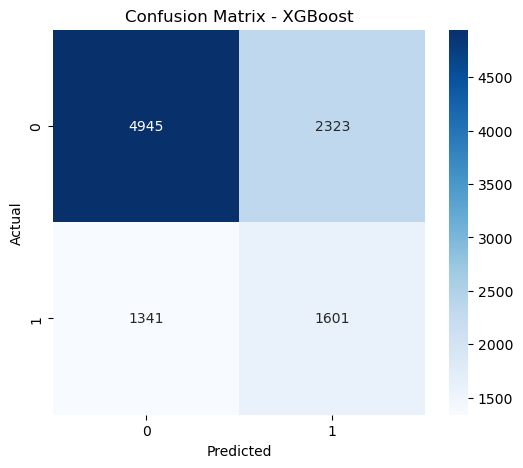

In [63]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [64]:
print("="*60)
print("Cross Validation")
print("="*60)

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("F1 Scores:", np.round(cv_scores,4))

print(f"\nMean F1 : {cv_scores.mean():.4f}")

print(f"Std F1  : {cv_scores.std():.4f}")

Cross Validation
F1 Scores: [0.4507 0.4578 0.4481 0.4562 0.4626]

Mean F1 : 0.4551
Std F1  : 0.0052


In [65]:
print("="*60)
print("Final Model Summary")
print("="*60)

print(f"Selected Model : {best_model_name}")

print(f"Accuracy : {results_df.iloc[0]['Accuracy']:.4f}")

print(f"Precision: {results_df.iloc[0]['Precision']:.4f}")

print(f"Recall   : {results_df.iloc[0]['Recall']:.4f}")

print(f"F1 Score : {results_df.iloc[0]['F1-Score']:.4f}")

print(f"ROC AUC  : {results_df.iloc[0]['ROC-AUC']:.4f}")

Final Model Summary
Selected Model : XGBoost
Accuracy : 0.6411
Precision: 0.4080
Recall   : 0.5442
F1 Score : 0.4664
ROC AUC  : 0.6618


In [72]:
best_model = grid.best_estimator_

In [73]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("XGBoost After Hyperparameter Tuning")
print("=" * 50)

print(classification_report(y_test, y_pred))

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

XGBoost After Hyperparameter Tuning
              precision    recall  f1-score   support

           0       0.81      0.60      0.69      7268
           1       0.40      0.65      0.50      2942

    accuracy                           0.62     10210
   macro avg       0.61      0.63      0.59     10210
weighted avg       0.69      0.62      0.63     10210

Accuracy : 0.6167482859941235
Precision: 0.3992947521261149
Recall   : 0.6543167912984365
F1 Score : 0.49594229035166815
ROC AUC  : 0.6778351841341331


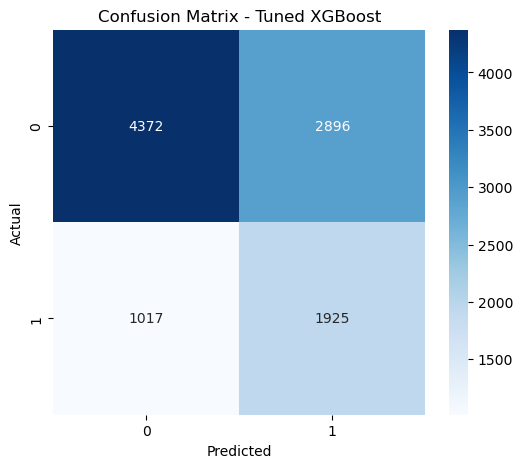

In [74]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Tuned XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [75]:
cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("Cross Validation Scores:", cv_scores)
print("Mean:", cv_scores.mean())
print("Std :", cv_scores.std())

Cross Validation Scores: [0.48947198 0.50235734 0.49098065 0.50833199 0.48880902]
Mean: 0.495990194436197
Std : 0.00789952285698438


In [76]:
"""
Hyperparameter tuning was applied to the XGBoost model using GridSearchCV. Although the overall accuracy decreased slightly from 64.11% to 61.67%, the tuned model achieved higher Recall (54.42% → 65.43%), higher F1-score (46.64% → 49.59%), and higher ROC-AUC (66.18% → 67.78%). Since customer churn prediction focuses on identifying as many churn customers as possible, the tuned XGBoost model was selected as the final mode
"""

'\nHyperparameter tuning was applied to the XGBoost model using GridSearchCV. Although the overall accuracy decreased slightly from 64.11% to 61.67%, the tuned model achieved higher Recall (54.42% → 65.43%), higher F1-score (46.64% → 49.59%), and higher ROC-AUC (66.18% → 67.78%). Since customer churn prediction focuses on identifying as many churn customers as possible, the tuned XGBoost model was selected as the final mode\n'